Tutorial: https://salib.readthedocs.io/en/latest/user_guide/basics.html

In [1]:
from SALib.sample import saltelli ##saltelli is a type of sampling implemented in SALib
from SALib.analyze import sobol ##sobol is a type of SA analysis implemented in SALib
from SALib.test_functions import Ishigami
import numpy as np

### Sobol sensitivity analysis of Ishigami function using SALib functions.

##### Define the model inputs

In [2]:
problem = {
    'num_vars': 3,
    'names': ['x1', 'x2', 'x3'],
    'bounds': [[-3.14159265359, 3.14159265359],
               [-3.14159265359, 3.14159265359],
               [-3.14159265359, 3.14159265359]]
}

#### Generate samples

In [3]:
# Generate samples using Saltelli sampler
param_values =  saltelli.sample(problem, 1024)
param_values.shape

'''The Saltelli sampler generates N*(2D +2) samples, where in this example N is 1024 
(the argument we supplied) and D is 3 (the number of model inputs). '''

'''The keyword argument calc_second_order=False will exclude second-order indices, 
resulting in a smaller sample matrix with N*(D+2) rows instead.'''

/tmp/ipykernel_48612/1607725629.py:2: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5. Please use `salib.sample.sobol`
  param_values =  saltelli.sample(problem, 1024)


'The keyword argument calc_second_order=False will exclude second-order indices, \nresulting in a smaller sample matrix with N*(D+2) rows instead.'

#### Run model

In [4]:
## Saving the samples (if model is not written in python)
#np.savetxt('param_values.txt', param_values) Each horizontal line in param_values.txt is one input to the model.
## Load output from external model (one output on each line)
#Y = np.loadtxt("outputs.txt", float) The output has one output on each horizontal line.
## Evaluate Ishigami function
Y = Ishigami.evaluate(param_values)

#### Perform analysis

In [18]:
# Perform analysis: Compute sensitivity indices
Si = sobol.analyze(problem, Y, print_to_console=False) 
'''Output: 
S1: First-order indices 
S2: Second-order indices
ST: Total order index
S1_conf, S2_conf, ST_conf: Confidence intervals'''

'''
    First-order indices: measures the contribution to the output variance by a single model input alone.

    Second-order indices: measures the contribution to the output variance caused by the interaction of two model inputs.

    Total-order index: measures the contribution to the output variance caused by a model input, including both its first-order effects (the input varying alone) and all higher-order interactions.
'''
print(Si['S2'])

print("x1-x2:", Si['S2'][0,1])
print("x1-x3:", Si['S2'][0,2])
print("x2-x3:", Si['S2'][1,2])

# Note that if the sample was created with `calc_second_order=False`
# Then the second order sensitivities will not be returned

[[        nan  0.00925429  0.23817211]
 [        nan         nan -0.0048877 ]
 [        nan         nan         nan]]
x1-x2: 0.009254293034908045
x1-x3: 0.23817210956856472
x2-x3: -0.004887704633467388


In [19]:
#Convert to data frame
total_Si, first_Si, second_Si = Si.to_df()

array([<Axes: >, <Axes: >, <Axes: >], dtype=object)

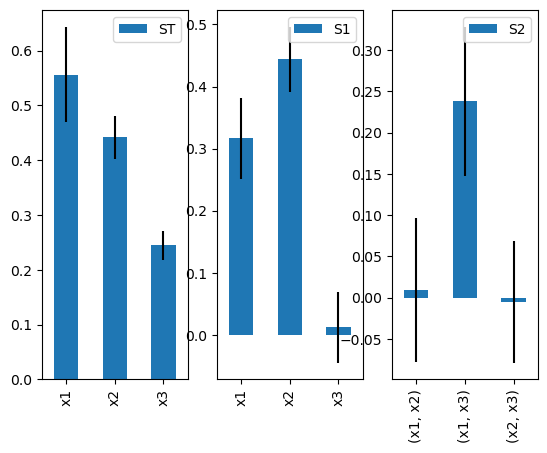

In [20]:
#Ploting
Si.plot()

### Physicell example: Marco Ruscone code LHS sampling

In [3]:
# Define the number of samples and parameters
#num_samples = int(sys.argv[1])
num_params = 8

#### Model input 

In [4]:
# Define the ranges for each parameter
param_ranges = {
    'cell_ecm_repulsion': [0, 75],
    'contact_cell_ECM_threshold': [0, 2],
    'contact_cell_cell_threshold': [0, 3.5],
    'cell_junctions_attach_threshold': [0, 1],
    'cell_junctions_detach_threshold': [0, 1],
    'migration_bias': [0, 1],
    'migration_speed': [0, 1],
    'persistence': [0, 100]
}

problem = {
    'num_vars': 8,
    'names': list(param_ranges.keys()),
    'bounds': [[0, 75], [0, 2], [0, 3.5], [0, 1], [0, 1], [0, 1], [0, 1], [0, 100]]
}

#### Generate samples

In [5]:
# Generate the Latin hypercube samples
from SALib.sample import latin
lhs_samples = latin.sample(problem, 1024)

In [6]:
param_names = list(param_ranges.keys())
param_names_str = ','.join(param_names)

In [7]:
import pandas as pd
lhs_samples = pd.DataFrame(lhs_samples, columns=param_names)

In [8]:
#lhs_samples = pd.concat([pd.Series([param_names_str]), lhs_samples], axis=0, ignore_index=True)
print(pd.Series([param_names_str]))

0    cell_ecm_repulsion,contact_cell_ECM_threshold,...
dtype: object


#### Generate subspace

In [12]:
# Generate subspace
num_files = 4

# Calculate the number of rows in each output file
rows_per_file = int(len(lhs_samples) / num_files)

# Loop over the number of output files to generate
for i in range(num_files):
    # Calculate the start and end indices for the current output file
    start_idx = i * rows_per_file
    end_idx = (i + 1) * rows_per_file

    # If this is the last file, include any remaining rows
    if i == num_files - 1:
        end_idx = len(lhs_samples)

    # Extract the rows for the current output file
    rows = lhs_samples.iloc[start_idx:end_idx]

    # Write the rows to a new CSV file
    filename = f'saltelli_samples_{i}.csv'
    rows.to_csv(filename, index=False)

In [14]:
param_names = {"cell_ecm_repulsion": 0, "contact_cell_ECM_threshold": 1, "contact_cell_cell_threshold": 2, "cell_junctions_attach_threshold": 3,
               "cell_junctions_detach_threshold": 4, "migration_bias": 5, "migration_speed": 6, "persistence":7}
print(param_names.items())

dict_items([('cell_ecm_repulsion', 0), ('contact_cell_ECM_threshold', 1), ('contact_cell_cell_threshold', 2), ('cell_junctions_attach_threshold', 3), ('cell_junctions_detach_threshold', 4), ('migration_bias', 5), ('migration_speed', 6), ('persistence', 7)])


In [20]:
for i, lhs_iteration in enumerate(lhs_samples):
    for param_name, lhs_col_index in param_names.items():
        print(lhs_iteration[lhs_col_index])



c
e
l
l
_
e
c
m
c
o
n
t
a
c
t
_
c
o
n
t
a
c
t
_
c
e
l
l
_
j
u
n
c
e
l
l
_
j
u
n
m
i
g
r
a
t
i
o
m
i
g
r
a
t
i
o
p
e
r
s
i
s
t
e
